In [1]:
!pip install neuralforecast


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [3]:
# Load Feature dataset
cpu_df = pd.read_csv(
    "../data/Processed/cpu_baseline.csv"
)

cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)

In [4]:
# PatchTST Format: 
# NeuralForecast requires: unique_id, ds, y
patch_df = cpu_df.copy()
patch_df = patch_df.rename(
    columns={
        "hostName":"unique_id",
        "ts":"ds",
        "cpu_usage_pct":"y"
    }
)

In [5]:
# Keep needed columns
patch_df = patch_df[
    [
        "unique_id",
        "ds",
        "y",

        "memory_usage_pct",
        "power_kw",
        "cpu_temp_c",

        "resource_stress_index",

        "hour_of_day",
        "day_of_week",
        "is_weekend"
    ]
]
# Sort
patch_df = patch_df.sort_values(
    ["unique_id","ds"]
)

In [6]:
# Train-test split
# We'll forecast: 24 hours
# which equals: 288 timestamps
horizon = 288
train_df = (
    patch_df
    .groupby("unique_id")
    .apply(
        lambda x:
        x.iloc[:-horizon]
    )
    .reset_index(drop=True)
)
test_df = (
    patch_df
    .groupby("unique_id")
    .apply(
        lambda x:
        x.iloc[-horizon:]
    )
    .reset_index(drop=True)
)

C:\Users\Avilasha\AppData\Local\Temp\ipykernel_11608\3905820690.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\Avilasha\AppData\Local\Temp\ipykernel_11608\3905820690.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [7]:
# PatchTST Model
model = PatchTST(
    h=horizon,
    input_size=576,
    hidden_size=64,
    n_heads=4,
    max_steps=500
)
# NeuralForecast 
nf = NeuralForecast(
    models=[model],
    freq="5min"
)
# Train
nf.fit(
    train_df
)
# Predict
forecast = nf.predict()
forecast["ds"] = (
    forecast["ds"]
    .dt.floor("5min")
)

test_df["ds"] = (
    test_df["ds"]
    .dt.floor("5min")
)

# Merge Actual + Forecast
results = (
    test_df.merge(
        forecast,
        on=["unique_id","ds"]
    )
)

print("Forecast shape:", forecast.shape)
print("Test shape:", test_df.shape)

forecast.head()


Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 1.5 M  | train
-----------------------------------------------------------
1.5 M     Trainable params
3         Non-trainable params
1.5 M     Total params
5.932     Total e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Forecast shape: (864, 3)
Test shape: (864, 10)


,unique_id,ds,PatchTST
0,10.10.10.150,2026-06-10 04:40:00+00:00,2.971752
1,10.10.10.150,2026-06-10 04:45:00+00:00,2.976730
2,10.10.10.150,2026-06-10 04:50:00+00:00,3.001653
3,10.10.10.150,2026-06-10 04:55:00+00:00,2.760344
4,10.10.10.150,2026-06-10 05:00:00+00:00,2.759119


In [8]:
test_df.head()

,unique_id,ds,y,memory_usage_pct,power_kw,cpu_temp_c,resource_stress_index,hour_of_day,day_of_week,is_weekend
0,10.10.10.150,2026-06-10 04:40:00+00:00,2.72,34.83,0.221,48,18.775,4,2,0
1,10.10.10.150,2026-06-10 04:45:00+00:00,2.08,34.83,0.202,48,18.455,4,2,0
2,10.10.10.150,2026-06-10 04:50:00+00:00,1.98,34.83,0.207,47,18.405,4,2,0
3,10.10.10.150,2026-06-10 04:55:00+00:00,2.24,34.83,0.242,50,18.535,4,2,0
4,10.10.10.150,2026-06-10 05:00:00+00:00,2.05,34.83,0.249,49,18.440,5,2,0


In [9]:
print(forecast["ds"].min())
print(forecast["ds"].max())

print(test_df["ds"].min())
print(test_df["ds"].max())

2026-06-10 04:40:00+00:00
2026-06-11 04:35:00+00:00
2026-06-10 04:40:00+00:00
2026-06-11 04:25:00+00:00


In [10]:
print(forecast.dtypes)
print(test_df.dtypes)

forecast["ds"]
test_df["ds"]

forecast.head()
forecast.tail()

print(forecast.shape)

print(test_df.shape)

results["PatchTST"].isnull().sum()

unique_id                 object
ds           datetime64[ns, UTC]
PatchTST                 float32
dtype: object
unique_id                             object
ds                       datetime64[ns, UTC]
y                                    float64
memory_usage_pct                     float64
power_kw                             float64
cpu_temp_c                             int64
resource_stress_index                float64
hour_of_day                            int64
day_of_week                            int64
is_weekend                             int64
dtype: object
(864, 3)
(864, 10)


np.int64(0)

In [11]:
# Metrics
mae = mean_absolute_error(
    results["y"],
    results["PatchTST"]
)

rmse = np.sqrt(
    mean_squared_error(
        results["y"],
        results["PatchTST"]
    )
)

r2 = r2_score(
    results["y"],
    results["PatchTST"]
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.1083646972643004
RMSE: 1.6951809767091874
R²  : 0.9795868169079816


In [ ]:
# Verify Results DataFrame
print(results.shape)
results.head()

(864, 11)


,unique_id,ds,y,memory_usage_pct,power_kw,cpu_temp_c,resource_stress_index,hour_of_day,day_of_week,is_weekend,PatchTST
0,10.10.10.150,2026-06-10 04:40:00+00:00,2.72,34.83,0.221,48,18.775,4,2,0,2.971752
1,10.10.10.150,2026-06-10 04:45:00+00:00,2.08,34.83,0.202,48,18.455,4,2,0,2.976730
2,10.10.10.150,2026-06-10 04:50:00+00:00,1.98,34.83,0.207,47,18.405,4,2,0,3.001653
3,10.10.10.150,2026-06-10 04:55:00+00:00,2.24,34.83,0.242,50,18.535,4,2,0,2.760344
4,10.10.10.150,2026-06-10 05:00:00+00:00,2.05,34.83,0.249,49,18.440,5,2,0,2.759119


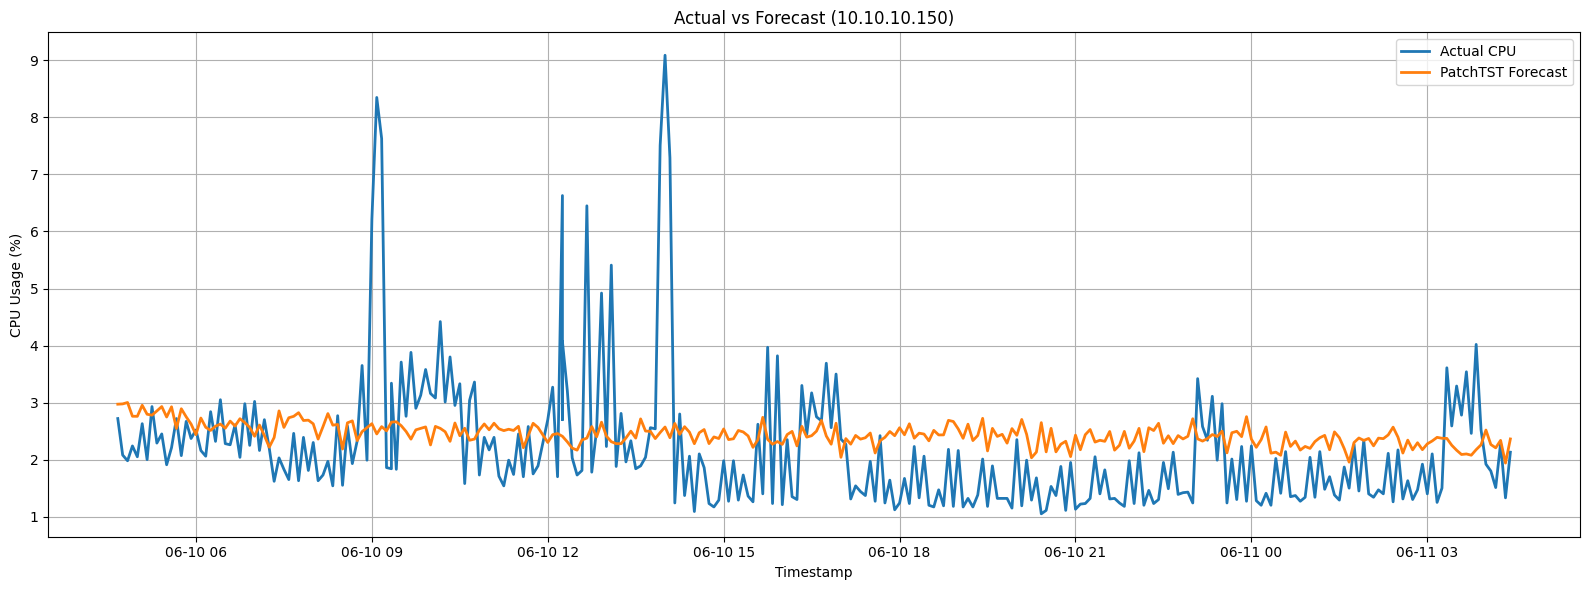

In [13]:
# Plot actual vs Prediction
server = "10.10.10.150"
plot_df = (
    results[
        results["unique_id"] == server
    ]
    .sort_values("ds")
)
plt.figure(
    figsize=(16,6)
)
plt.plot(
    plot_df["ds"],
    plot_df["y"],
    label="Actual CPU",
    linewidth=2
)
plt.plot(
    plot_df["ds"],
    plot_df["PatchTST"],
    label="PatchTST Forecast",
    linewidth=2
)
plt.title(
    f"Actual vs Forecast ({server})"
)
plt.xlabel("Timestamp")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

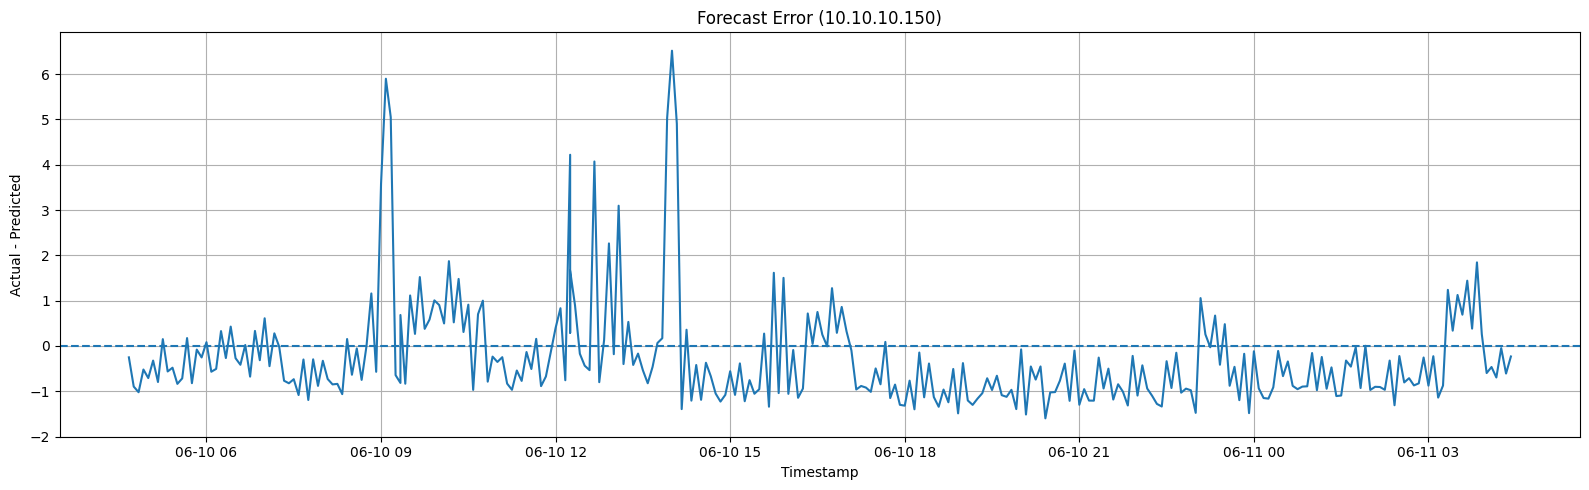

In [14]:
# Forecast error plot
plot_df["error"] = (
    plot_df["y"]
    - plot_df["PatchTST"]
)

plt.figure(
    figsize=(16,5)
)

plt.plot(
    plot_df["ds"],
    plot_df["error"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    f"Forecast Error ({server})"
)

plt.xlabel("Timestamp")
plt.ylabel("Actual - Predicted")

plt.grid(True)

plt.tight_layout()

plt.show()

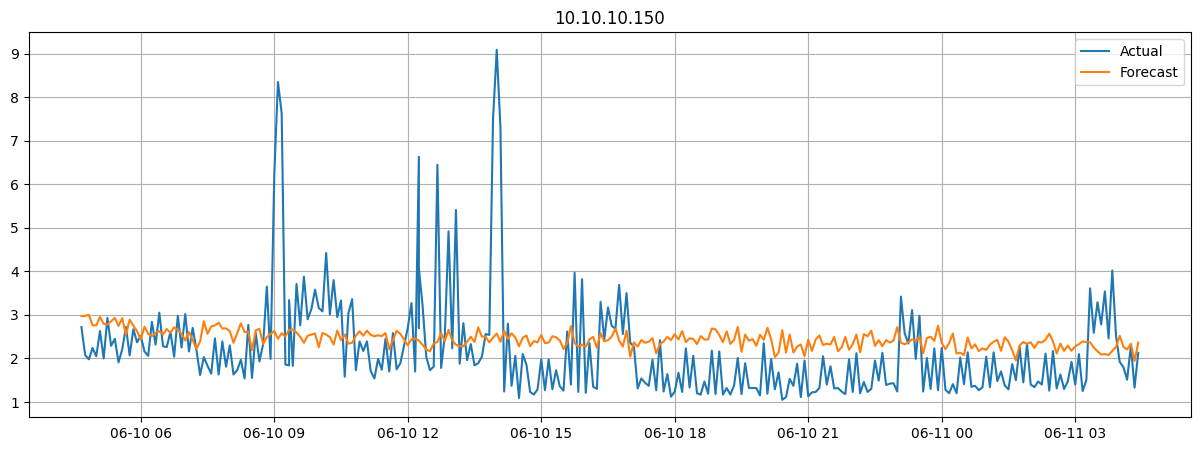

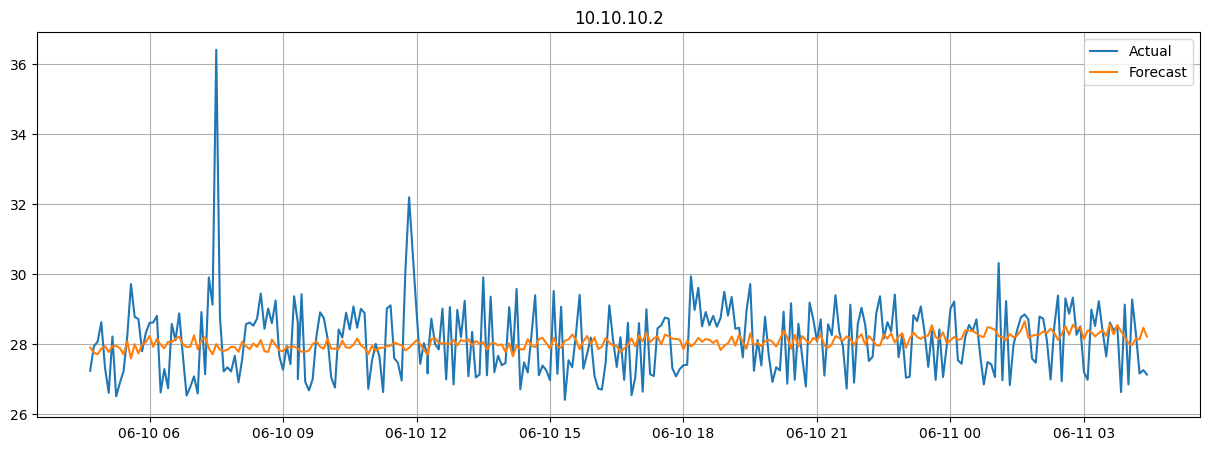

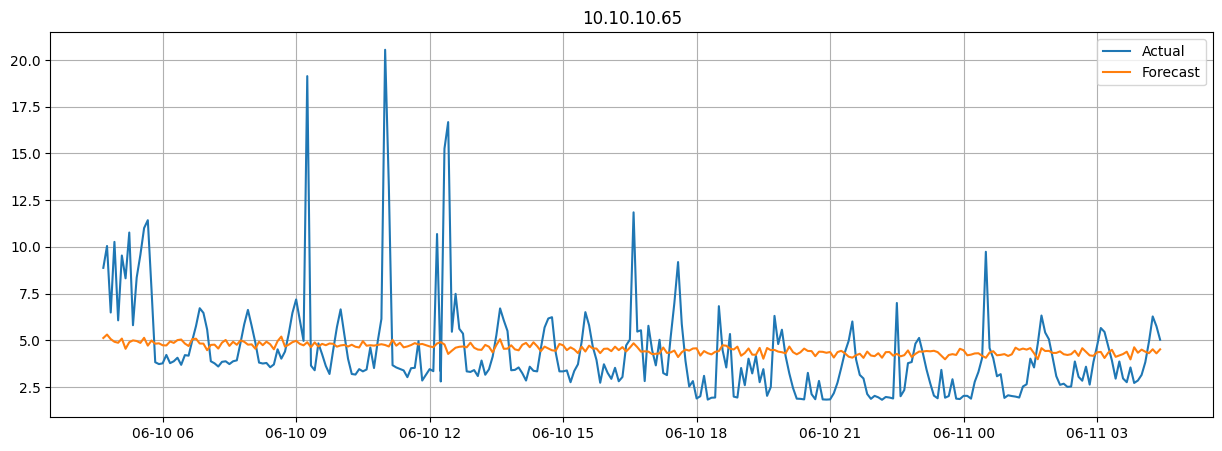

In [15]:
# Plot all servers separately

for server in results["unique_id"].unique():

    plot_df = (
        results[
            results["unique_id"] == server
        ]
        .sort_values("ds")
    )

    plt.figure(
        figsize=(15,5)
    )

    plt.plot(
        plot_df["ds"],
        plot_df["y"],
        label="Actual"
    )

    plt.plot(
        plot_df["ds"],
        plot_df["PatchTST"],
        label="Forecast"
    )

    plt.title(server)

    plt.legend()

    plt.grid(True)

    plt.show()

In [16]:
# Veirfying no leakage
results[["y","PatchTST"]].corr()

,y,PatchTST
y,1.000000,0.989861
PatchTST,0.989861,1.000000


In [18]:
results.head()


,unique_id,ds,y,memory_usage_pct,power_kw,cpu_temp_c,resource_stress_index,hour_of_day,day_of_week,is_weekend,PatchTST
0,10.10.10.150,2026-06-10 04:40:00+00:00,2.72,34.83,0.221,48,18.775,4,2,0,2.971752
1,10.10.10.150,2026-06-10 04:45:00+00:00,2.08,34.83,0.202,48,18.455,4,2,0,2.976730
2,10.10.10.150,2026-06-10 04:50:00+00:00,1.98,34.83,0.207,47,18.405,4,2,0,3.001653
3,10.10.10.150,2026-06-10 04:55:00+00:00,2.24,34.83,0.242,50,18.535,4,2,0,2.760344
4,10.10.10.150,2026-06-10 05:00:00+00:00,2.05,34.83,0.249,49,18.440,5,2,0,2.759119


In [19]:
results.tail()

,unique_id,ds,y,memory_usage_pct,power_kw,cpu_temp_c,resource_stress_index,hour_of_day,day_of_week,is_weekend,PatchTST
859,10.10.10.65,2026-06-11 04:05:00+00:00,3.83,81.75,0.220,40,42.79,4,3,0,4.392503
860,10.10.10.65,2026-06-11 04:10:00+00:00,4.94,81.76,0.220,38,43.35,4,3,0,4.315270
861,10.10.10.65,2026-06-11 04:15:00+00:00,6.28,81.76,0.220,41,44.02,4,3,0,4.522751
862,10.10.10.65,2026-06-11 04:20:00+00:00,5.76,81.76,0.221,42,43.76,4,3,0,4.303521
863,10.10.10.65,2026-06-11 04:25:00+00:00,5.03,81.75,0.221,41,43.39,4,3,0,4.519456
